In [3]:
import pandas as pd
pd.__version__


df = pd.read_pickle('../data/LSWMD_slimmed.pkl')
df.info()

<class 'pandas.DataFrame'>
Index: 12822 entries, 19 to 811447
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   waferMap  12822 non-null  object
 1   label     12822 non-null  str   
dtypes: object(1), str(1)
memory usage: 300.5+ KB


In [4]:
import tensorflow as tf
import numpy as np



TARGET_SIZE = (96, 96) 

def wafertoscale(wafer_matrix): #preprocesses single wafermap
   
    tensor = tf.convert_to_tensor(wafer_matrix, dtype=tf.float32)  
    tensor = tf.expand_dims(tensor, axis=-1) # Add the channel dimension: (Height, Width) -> (Height, Width, 1)

    # Resize with pad:
    resized_tensor = tf.image.resize_with_pad(
        tensor, 
        target_height=TARGET_SIZE[0], 
        target_width=TARGET_SIZE[1], 
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )
    #print(tensor.shape,resized_tensor.shape)

    return resized_tensor.numpy()

# Apply preprocessing to all wafers
df['processed_waferMap'] = [wafertoscale(w) for w in df['waferMap']]
X_processed = np.stack([wafertoscale(w) for w in df['waferMap']])

print(f"Final Image Data Shape: {X_processed.shape}") 

df.head()


2026-05-14 16:17:04.715658: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Final Image Data Shape: (12822, 96, 96, 1)


,waferMap,label,processed_waferMap
19,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",Loc,"[[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0..."
36,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",Edge-Loc,"[[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0..."
39,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",Edge-Loc,"[[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0..."
40,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",Loc,"[[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0..."
41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",Edge-Loc,"[[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0..."


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['label']) #convert string labels to integers for training and to do test train split

NUM_CLASSES = len(label_encoder.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, 
    y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)


X_train = X_train.astype(np.int8)
X_test = X_test.astype(np.int8)

np.savez_compressed(
    'wafer_dataset_96x96.npz', 
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    y_test=y_test
)

In [6]:
from datasets import WM_811K_preprocessed

ds2 = WM_811K_preprocessed()

# Extract the arrays
X_train = ds2.X_train
y_train = ds2.labels_train
X_test = ds2.X_test
y_test = ds2.labels_test

# Re-wrap into tf.data.Dataset instantly
BATCH_SIZE = 32
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train)).batch(BATCH_SIZE)

BATCH_SIZE = 32

# Create Training Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = (
    train_dataset
    .shuffle(buffer_size=len(X_train)) # Shuffle the training data
    .batch(BATCH_SIZE)                 # Group into batches of 32
    .prefetch(tf.data.AUTOTUNE)        # Pre-fetch next batch in the background
)

# Create Testing/Validation Dataset
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = (
    test_dataset
    .batch(BATCH_SIZE)                 
    .prefetch(tf.data.AUTOTUNE)
)

In [7]:
# CNN model
model = tf.keras.models.Sequential([
    # ---- Conv block 1 -------------------------------------------------
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu',
                           input_shape=(96, 96, 1)),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # ---- Conv block 2 -------------------------------------------------
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # ---- Conv block 3 -------------------------------------------------
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # ---- Flatten + Dense -----------------------------------------------
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])

model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics = ['accuracy']
)

model.summary()

/Users/david/Documents/GitHub/NTU_Data_Analysis/env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 47, 47, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 22, 22, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         4,617 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,338,313 (12.73 MB)

 Trainable params: 3,337,993 (12.73 MB)

 Non-trainable params: 320 (1.25 KB)

In [8]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

callbacks = [
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=3,
        verbose=1,
        min_lr=1e-7
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_wafer_cnn.keras', 
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    x=train_dataset,                
    validation_data=test_dataset,   
    epochs=50,                      
    callbacks=callbacks,
    verbose=1                       
)

Epoch 1/50
321/321 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.4860 - loss: 1.7744
Epoch 1: val_accuracy improved from None to 0.17115, saving model to best_wafer_cnn.keras

Epoch 1: finished saving model to best_wafer_cnn.keras
321/321 ━━━━━━━━━━━━━━━━━━━━ 79s 234ms/step - accuracy: 0.5579 - loss: 1.3002 - val_accuracy: 0.1712 - val_loss: 4.6643 - learning_rate: 0.0010
Epoch 2/50
321/321 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.6480 - loss: 0.9384
Epoch 2: val_accuracy improved from 0.17115 to 0.66394, saving model to best_wafer_cnn.keras

Epoch 2: finished saving model to best_wafer_cnn.keras
321/321 ━━━━━━━━━━━━━━━━━━━━ 79s 245ms/step - accuracy: 0.6544 - loss: 0.9163 - val_accuracy: 0.6639 - val_loss: 0.9152 - learning_rate: 0.0010
Epoch 3/50
321/321 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.6959 - loss: 0.8262
Epoch 3: val_accuracy did not improve from 0.66394
321/321 ━━━━━━━━━━━━━━━━━━━━ 82s 256ms/step - accuracy: 0.7053 - loss: 0.8070 - val_accuracy: 0.6476 -

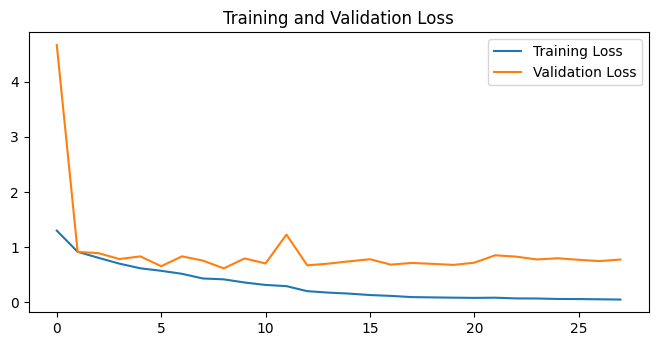

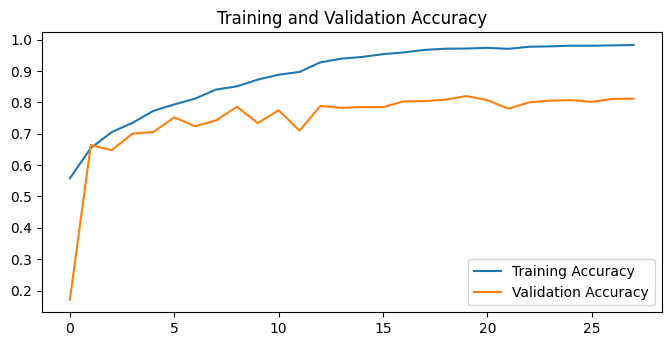

In [10]:
import matplotlib.pyplot as plt

# Training Loss
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()



# Training Accuracy
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 2)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.show()